In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats

In [13]:
df = pd.read_csv("Dataset_1.csv")
print(df.head())

  Student_ID   Age  Gender        Department  Year_of_Study  \
0  STU-01046  22.0  Female        Mechanical              1   
1  STU-01198  20.0  Female  Computer Science              2   
2  STU-00203  21.0    Male       Electronics              1   
3  STU-00822  17.0  Female  Computer Science              4   
4  STU-00638  23.0    Male             Civil              3   

         Residence_Type Parent_Education Internet_Access Part_Time_Job  \
0           With Family           School             Yes            No   
1  Rented Accommodation           School             Yes            No   
2  Rented Accommodation         Graduate             Yes            No   
3           With Family         Graduate             Yes            No   
4                Hostel           School             Yes            No   

   Study_Hours_Per_Day  ...  Attendance_Percentage  Assignment_Delay_Days  \
0                 2.73  ...                 100.00                    1.0   
1                 1.41

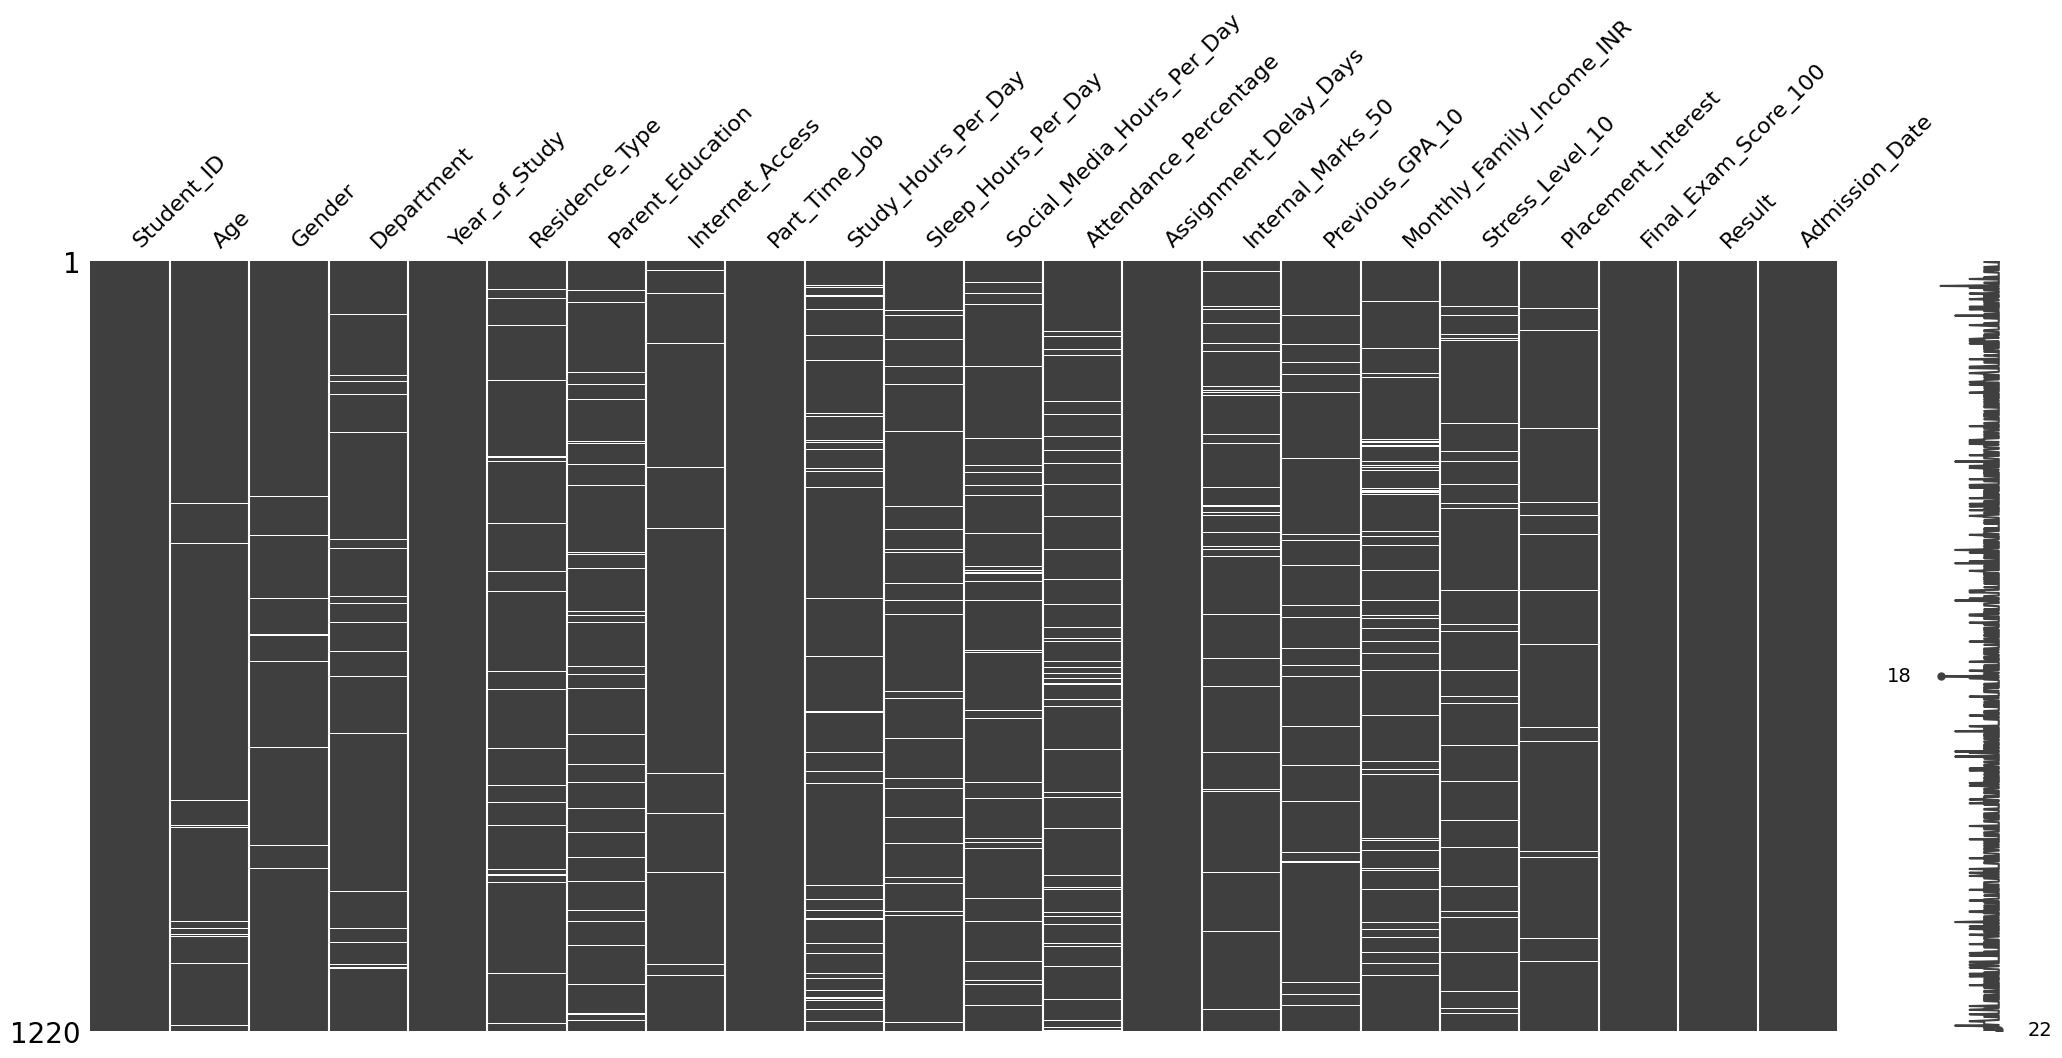

In [14]:
msno.matrix(df)
plt.show()

df_deleted = df.dropna()

numeric_cols = df.select_dtypes(include=np.number).columns
df_imputed = df.copy()
df_imputed[numeric_cols] = df_imputed[numeric_cols].fillna(df_imputed[numeric_cols].median())

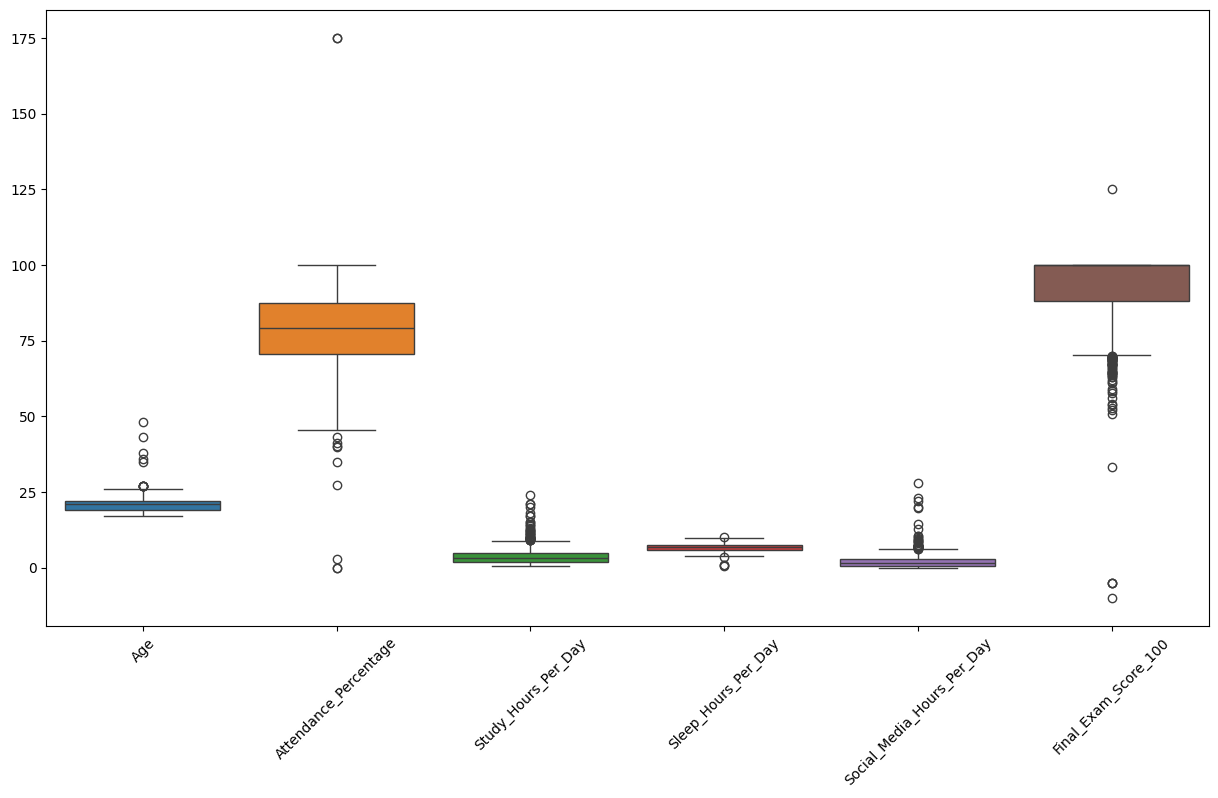

In [19]:
outlier_cols = ['Age', 'Attendance_Percentage', 'Study_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Media_Hours_Per_Day', 'Monthly_Family_Income_INR', 'Final_Exam_Score_100']

plt.figure(figsize=(15, 8))
sns.boxplot(data=df[outlier_cols])
plt.xticks(rotation=45)
plt.show()

df_numeric = df[outlier_cols].apply(lambda x: pd.to_numeric(x, errors='coerce'))

Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1

iqr_outliers = ((df_numeric < (Q1 - 1.5 * IQR)) | (df_numeric > (Q3 + 1.5 * IQR))).sum()

In [21]:
skewed_cols = ['Study_Hours_Per_Day', 'Social_Media_Hours_Per_Day', 'Assignments_Delay_Days', 'Monthly_Family_Income_INR']

print(df.columns.tolist())

skewness_vals = df[skewed_cols].skew()

for col in skewed_cols:
    df[f'{col}_Log'] = np.log1p(df[col])

['Student_ID', 'Age', 'Gender', 'Department', 'Year_of_Study', 'Residence_Type', 'Parent_Education', 'Internet_Access', 'Part_Time_Job', 'Study_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Media_Hours_Per_Day', 'Attendance_Percentage', 'Assignment_Delay_Days', 'Internal_Marks_50', 'Previous_GPA_10', 'Monthly_Family_Income_INR', 'Stress_Level_10', 'Placement_Interest', 'Final_Exam_Score_100', 'Result', 'Admission_Date']


KeyError: "['Assignments_Delay_Days'] not in index"

In [ ]:
duplicate_count = df.duplicated().sum()

df = df.drop_duplicates()

In [ ]:
cat_cols = ['Department', 'Placement_Interest', 'Parent_Education']

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(col)
    plt.show()

In [ ]:
df.loc[df['Attendance'] > 100, 'Attendance'] = np.nan

df.loc[(df['Exam_Score'] < 0) | (df['Exam_Score'] > 100), 'Exam_Score'] = np.nan

In [ ]:
corr_cols = ['Study_Hours', 'Attendance', 'GPA', 'Internal_Marks', 'Exam_Score']

plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

sns.pairplot(df[corr_cols], kind='reg')
plt.show()

In [ ]:
X = df.drop(columns=['Result', 'Final_Exam_Score_100'], errors='ignore')

y_class = df['Result'] if 'Result' in df.columns else None

y_reg = df['Final_Exam_Score_100'] if 'Final_Exam_Score_100' in df.columns else None